In [1]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# We start by downloading the dataset
path = kagglehub.dataset_download("arjunbhaybhang/marine-institute-tide-prediction-dataset")

print("Path to dataset files:", path)

files_in_directory = os.listdir(path)
print("Archivos en el directorio:", files_in_directory)

csv_file_path = os.path.join(path, 'Tide Prediction.csv')

data = pd.read_csv(csv_file_path)
data = data.iloc[1:]#The first row of the dataset is titles.

print(data.head())

Path to dataset files: C:\Users\angel\.cache\kagglehub\datasets\arjunbhaybhang\marine-institute-tide-prediction-dataset\versions\1
Archivos en el directorio: ['Tide Prediction.csv']


C:\Users\angel\AppData\Local\Temp\ipykernel_5924\4283588312.py:11: DtypeWarning: Columns (1,2,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file_path)


                   time   longitude  latitude               stationID  \
1  2017-01-01T00:10:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
2  2017-01-01T00:20:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
3  2017-01-01T00:30:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
4  2017-01-01T00:40:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
5  2017-01-01T00:50:00Z  -10.101596  53.95219  Achill_Island_MODELLED   

  Water_Level Water_Level_ODM  
1        1.34           -1.23  
2         1.3           -1.27  
3        1.26           -1.31  
4        1.23           -1.34  
5        1.22           -1.35  


## Time Series Analysis

In [3]:
print('First row starts in: ' + data['time'].min(), 'last row is :' + data['time'].max())
# Data from 2017 to 2020
# 10 minutes margen between oone line to the next one

First row starts in: 2017-01-01T00:00:00Z last row is :2020-01-01T00:20:00Z


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6885393 entries, 1 to 6885393
Data columns (total 6 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   time             object
 1   longitude        object
 2   latitude         object
 3   stationID        object
 4   Water_Level      object
 5   Water_Level_ODM  object
dtypes: object(6)
memory usage: 315.2+ MB


In [5]:
data['time'] = pd.to_datetime(data['time'])
data['longitude'] = pd.to_numeric(data['longitude'])
data['latitude'] = pd.to_numeric(data['latitude'])
data['Water_Level'] = pd.to_numeric(data['Water_Level'])
data['Water_Level_ODM'] = pd.to_numeric(data['Water_Level_ODM'])

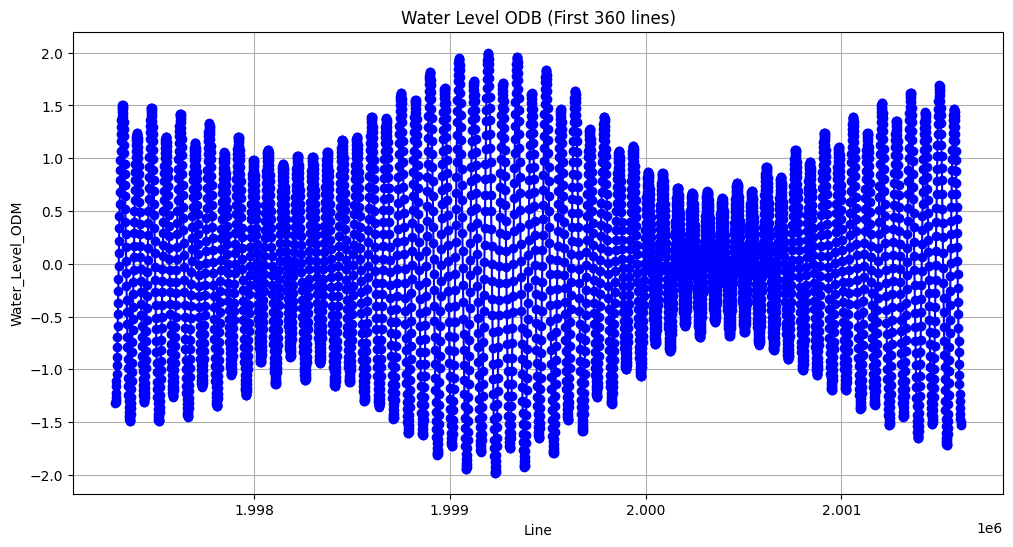

In [6]:
data_located = data[data['stationID'] == 'Dingle_Harbour_MODELLED']

primeras_100 = data_located.head(4320)

# This is the water lever over a day, we can see it seems to follow a patern
# This shows perfectly that in a day there are 2 high tides and 2 low tides
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 360 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

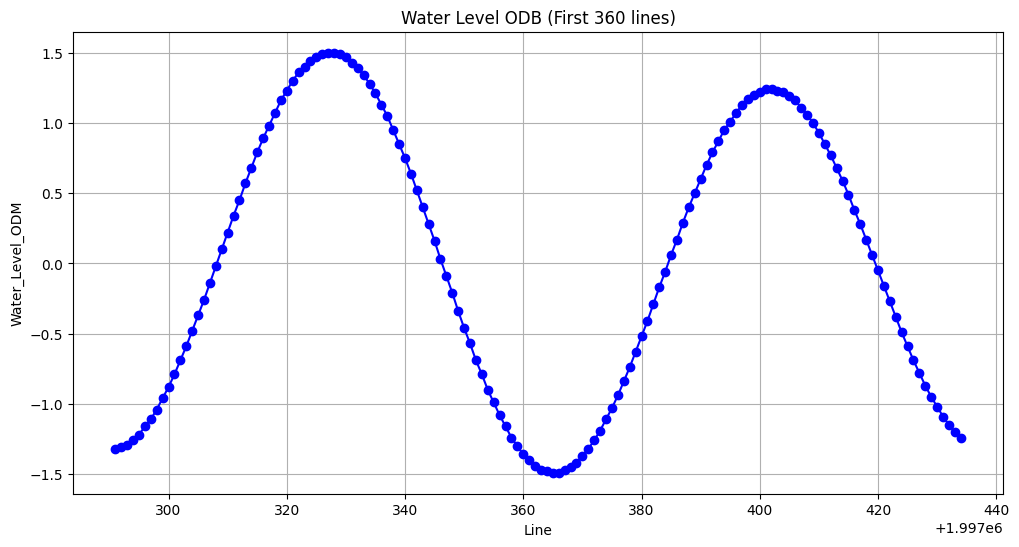

In [7]:
data_located = data[data['stationID'] == 'Dingle_Harbour_MODELLED']

primeras_100 = data_located.head(144)

# This is the water lever over a day, we can see it seems to follow a patern
# This shows perfectly that in a day there are 2 high tides and 2 low tides
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 360 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

In [8]:
# In the previous graph we can obseve there are 2 season each day, but according to the theory, wides contain 4 different season at the same time
# The can be regular but this might not be a problem as time series are usually not too strict with this.

# First: 12 hours 25 minutes (74.5 rows)
# Second: 24 hours 50 minutes (149 rows)
# Third: 14.76 days (2.125,44 rows)
# Four: 365 days (52.560 rows)

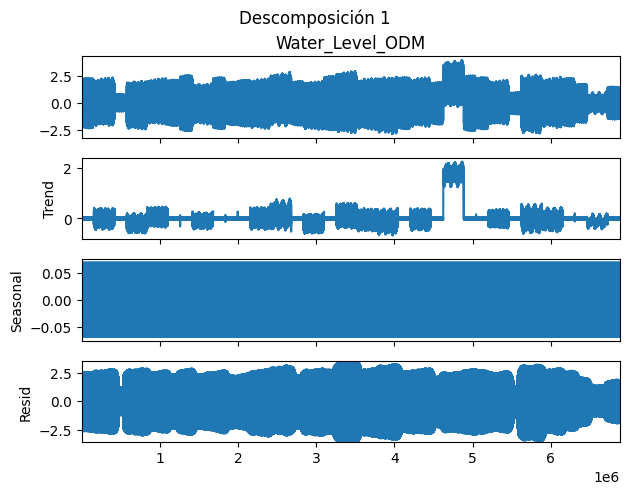

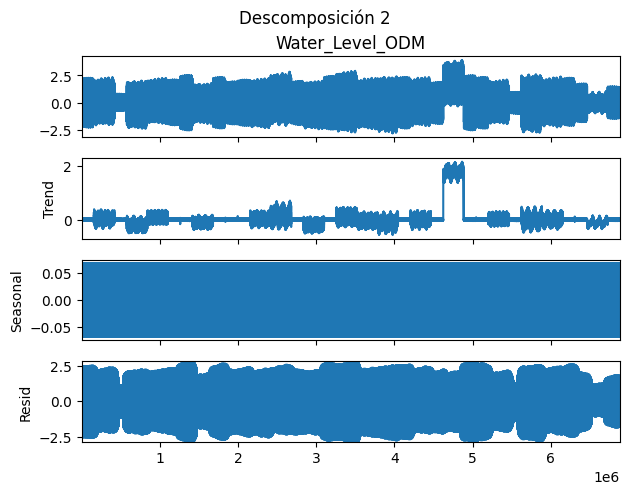

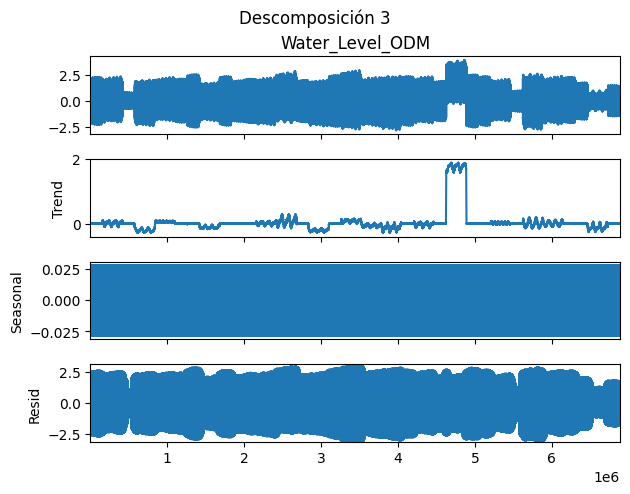

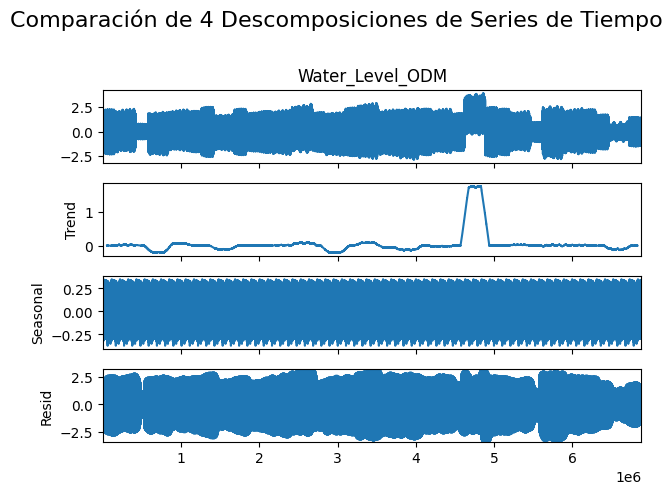

In [9]:
# Decomposition
# x must contain 2 complete cycles.
decomposition_1 = seasonal_decompose(data['Water_Level_ODM'], model='additive', period=74*2+1)
decomposition_2 = seasonal_decompose(data['Water_Level_ODM'], model='additive', period=149*2)
decomposition_3 = seasonal_decompose(data['Water_Level_ODM'], model='additive', period=2125*2+1)
decomposition_4 = seasonal_decompose(data['Water_Level_ODM'], model='additive', period=52560*2)

# Graficar cada descomposición en su respectivo subplot
decomposition_1.plot().suptitle('Descomposición 1', x=0.5, y=1.02)
decomposition_2.plot().suptitle('Descomposición 2', x=0.5, y=1.02)
decomposition_3.plot().suptitle('Descomposición 3', x=0.5, y=1.02)
decomposition_4.plot().suptitle('Descomposición 4', x=0.5, y=1.02)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Título principal
plt.suptitle('Comparación de 4 Descomposiciones de Series de Tiempo', fontsize=16, y=1.02)

plt.show()


In [10]:
# Analysis for yearly decomposition

# Observed: High var, lot of jumps, that can be because of the sensors-> missed data...
# Trend: Stable and flat during the whole data, means only change on the short run
#           Anomaly in an specific point: data error or something strange happened there
# Seasonality: Stable, simetric and repetitive, stationality is well detected.
# Residuals: Seems to be sparse but with patterns, that can be because it contains more that 1 seasonalitities  
#               It can be because the data is noisy itself, will later see the qq-plot!!      

In [ ]:
mstl = MSTL(data['Water_Level_ODM'], periods=[74*2+1, 149*2, 2125*2+1, 52560*2])
result = mstl.fit()
result.plot()